In [2]:
import numpy as np
import matplotlib.pyplot as plt

import os, sys
sys.path.insert(0, "/mnt/scratch/baburish/TPN-training/final/TPN_God")

import matplotlib.pyplot as plt
from lib.plotting import adjust_plot_1d

In [2]:
data = np.load('results.npy')


In [3]:
data.shape

(71, 21)

In [3]:
def GreatCircleDistance(azi_1, zen_1, azi_2, zen_2):
        ra_1 = azi_1
        ra_2 = azi_2
        dec_1 = np.pi/2.0 - zen_1
        dec_2 = np.pi/2.0 - zen_2
        '''Compute the great circle distance between two events'''
        '''All coordinates must be given in radians'''
        delta_dec = np.abs(dec_1 - dec_2)
        delta_ra = np.abs(ra_1 - ra_2)
        x = (np.sin(delta_dec / 2.))**2. + np.cos(dec_1) *\
            np.cos(dec_2) * (np.sin(delta_ra / 2.))**2.
        return 2. * np.arcsin(np.sqrt(x))

In [4]:
def get_gcd(results, result_idx=14):
    reco_zenith, reco_azimuth = results[:, result_idx], results[:, result_idx+1]
    track_src_v = results[:, 2:4]
    true_zenith, true_azimuth = track_src_v[:, 0], track_src_v[:, 1]
    smpe_zenith, smpe_azimuth = results[:, 8], results[:, 9]
    gcd = np.rad2deg(GreatCircleDistance(true_azimuth, true_zenith, reco_azimuth, reco_zenith))
    gcd_smpe = np.rad2deg(GreatCircleDistance(true_azimuth, true_zenith, smpe_azimuth, smpe_zenith))
    muon_energy = results[:, 0]
    return gcd, gcd_smpe, muon_energy

In [5]:
def get_resolution(results, result_idx=14):
    gcd, gcd_smpe, muon_energy = get_gcd(results, result_idx=result_idx)
       
    def get_quantiles(dpsi, energy, e_bins):
        lower, med, upper = [], [], []
        for el, eh in zip(e_bins[:-1], e_bins[1:]):
            #print(el, eh)
            idx = np.logical_and(energy >= el, energy < eh)
            l, m, u = np.percentile(dpsi[idx], [20, 50, 80])
            lower.append(l)
            med.append(m)
            upper.append(u)
        
        return lower, med, upper
    muon_energy = results[:, 0]
    print("Muon energy range:")
    print(f"  Min: {np.min(muon_energy):.2e}")
    print(f"  Max: {np.max(muon_energy):.2e}")
    print(f"  Log10 range: {np.log10(np.min(muon_energy)):.2f} to {np.log10(np.max(muon_energy)):.2f}")

    print(f"\nEnergy bins you're using: [2.0, 6.0]")
    print(f"Number of events in range: {np.sum((np.log10(muon_energy) >= 2.0) & (np.log10(muon_energy) < 6.0))}")
    # e_nu_range = [2.0, 6.0]
    muon_energy = results[:, 0]
    e_log = np.log10(muon_energy)
    e_min = np.floor(np.min(e_log) * 10) / 10  # Round down
    e_max = np.ceil(np.max(e_log) * 10) / 10   # Round up

    e_nu_range = [e_min, e_max]
    e_nu_bins = np.linspace(*e_nu_range, 21)
    centers = lambda x: 0.5 * (x[:-1]+x[1:])
    e_nu_centers = centers(e_nu_bins)
    lower, med, upper = get_quantiles(gcd, np.log10(muon_energy), e_nu_bins)
    lower2, med2, upper2 = get_quantiles(gcd_smpe, np.log10(muon_energy), e_nu_bins)

    return (lower, med, upper), (lower2, med2, upper2), e_nu_centers

In [18]:
r_seed_smpe, r_smpe, xvals = get_resolution(data, result_idx=15)
# r_seed_truth, _, _  = get_resolution(data_truth, result_idx=15)

Muon energy range:
  Min: 1.08e+03
  Max: 9.94e+03
  Log10 range: 3.03 to 4.00

Energy bins you're using: [2.0, 6.0]
Number of events in range: 71


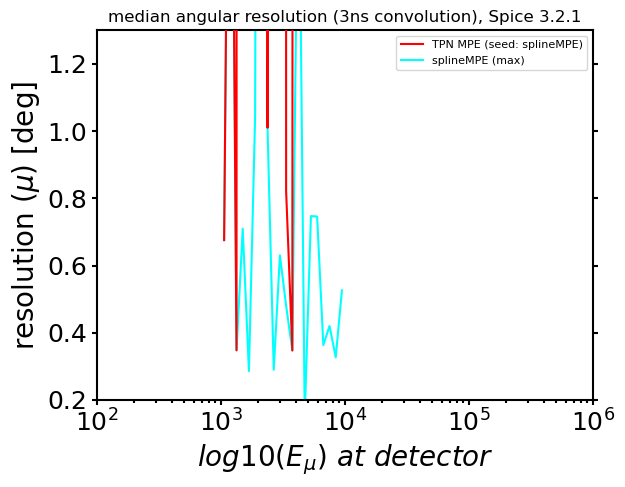

In [25]:
fig, ax = plt.subplots()
plot_args = {'xlabel':'$log10(E_{\\mu})\,\,at\,\,detector$', 
                 'ylabel':'resolution ($\mu$) [deg]', 
                 'xlim':[10**2.0, 10**6.0], 
                 'ylim':[0.2, 1.3]}

ax.plot(10**xvals, r_seed_smpe[1], color='red', label='TPN MPE (seed: splineMPE)', linestyle='solid', zorder=17)
# ax.plot(10**xvals, r_seed_truth[1], color='purple', label='TPN MPE (seed: truth)', linestyle='dashed', zorder=17)
ax.plot(10**xvals, r_smpe[1], color='cyan', label='splineMPE (max)')

adjust_plot_1d(fig, ax, plot_args=plot_args)
plt.xscale('log')
plt.title('median angular resolution (3ns convolution), Spice 3.2.1')
ax.set_yticks([0.2*i for i in range(9)][1:-2])
plt.legend(fontsize=8, loc='upper right')
plt.show()

In [21]:
gcd, gcd_smpe, _ = get_gcd(data, result_idx=15)

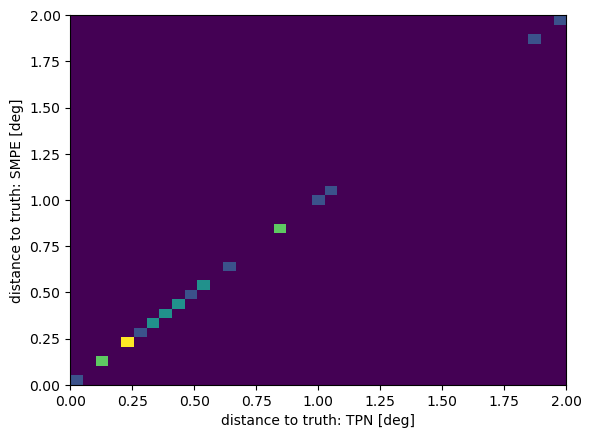

In [22]:
bins = np.linspace(0.0, 2.0, 40)
plt.hist2d(gcd, gcd_smpe, bins=bins)
plt.xlabel("distance to truth: TPN [deg]")
plt.ylabel("distance to truth: SMPE [deg]")
plt.show()

Text(0, 0.5, 'distance to truth: SMPE [deg]')

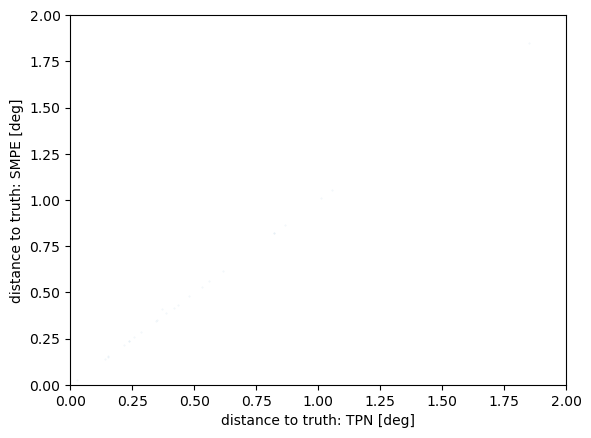

In [23]:
plt.scatter(gcd, gcd_smpe, s=0.1, alpha=0.1)
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 2.0)
plt.xlabel("distance to truth: TPN [deg]")
plt.ylabel("distance to truth: SMPE [deg]")

In [6]:
import pandas as pd
df = pd.read_csv('results.csv')
# OR
# df = pd.read_hdf('results.h5', 'results')
# OR
# df = pd.read_parquet('results.parquet')

def GreatCircleDistance(azi_1, zen_1, azi_2, zen_2):
    """Compute the great circle distance between two events"""
    """All coordinates must be given in radians"""
    ra_1 = azi_1
    ra_2 = azi_2
    dec_1 = np.pi/2.0 - zen_1
    dec_2 = np.pi/2.0 - zen_2
    
    delta_dec = np.abs(dec_1 - dec_2)
    delta_ra = np.abs(ra_1 - ra_2)
    x = (np.sin(delta_dec / 2.))**2. + np.cos(dec_1) * \
        np.cos(dec_2) * (np.sin(delta_ra / 2.))**2.
    return 2. * np.arcsin(np.sqrt(x))

def get_gcd(df):
    """Calculate great circle distances from DataFrame"""
    # Extract columns from DataFrame
    reco_zenith = df['reco_zenith'].values
    reco_azimuth = df['reco_azimuth'].values
    true_zenith = df['muon_zenith'].values
    true_azimuth = df['muon_azimuth'].values
    spline_zenith = df['spline_mpe_zenith'].values
    spline_azimuth = df['spline_mpe_azimuth'].values
    muon_energy = df['muon_energy_at_detector'].values
    
    # Calculate GCD
    gcd = np.rad2deg(GreatCircleDistance(true_azimuth, true_zenith, 
                                         reco_azimuth, reco_zenith))
    gcd_smpe = np.rad2deg(GreatCircleDistance(true_azimuth, true_zenith, 
                                              spline_azimuth, spline_zenith))
    
    return gcd, gcd_smpe, muon_energy

def get_quantiles(dpsi, energy, e_bins):
    """Calculate quantiles in energy bins"""
    lower, med, upper = [], [], []
    for el, eh in zip(e_bins[:-1], e_bins[1:]):
        idx = np.logical_and(energy >= el, energy < eh)
        if np.sum(idx) == 0:  # Skip empty bins
            continue
        l, m, u = np.percentile(dpsi[idx], [20, 50, 80])
        lower.append(l)
        med.append(m)
        upper.append(u)
    return lower, med, upper

def get_resolution(df):
    """Calculate resolution from DataFrame"""
    gcd, gcd_smpe, muon_energy = get_gcd(df)
    
    # Print energy statistics
    print("Muon energy range:")
    print(f"  Min: {np.min(muon_energy):.2e}")
    print(f"  Max: {np.max(muon_energy):.2e}")
    print(f"  Log10 range: {np.log10(np.min(muon_energy)):.2f} to {np.log10(np.max(muon_energy)):.2f}")
    
    # Create energy bins based on actual data range
    e_log = np.log10(muon_energy)
    e_min = np.floor(np.min(e_log) * 10) / 10  # Round down
    e_max = np.ceil(np.max(e_log) * 10) / 10   # Round up
    e_nu_range = [e_min, e_max]
    e_nu_bins = np.linspace(*e_nu_range, 21)
    
    print(f"\nEnergy bins: {e_nu_range}")
    print(f"Number of events in range: {np.sum((e_log >= e_nu_range[0]) & (e_log < e_nu_range[1]))}")
    
    # Calculate quantiles
    centers = lambda x: 0.5 * (x[:-1] + x[1:])
    e_nu_centers = centers(e_nu_bins)
    
    lower, med, upper = get_quantiles(gcd, e_log, e_nu_bins)
    lower2, med2, upper2 = get_quantiles(gcd_smpe, e_log, e_nu_bins)
    
    return (lower, med, upper), (lower2, med2, upper2), e_nu_centers

# Load and analyze
print("Loading results...")
df = pd.read_csv('results.csv')

print(f"\nDataFrame shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Calculate resolution
r_seed_smpe, r_smpe, xvals = get_resolution(df)

print(f"\nResolution calculated:")
print(f"  Reconstruction: {len(r_seed_smpe[1])} bins")
print(f"  SplineMPE: {len(r_smpe[1])} bins")

Loading results...

DataFrame shape: (71, 27)
Columns: ['muon_energy_at_detector', 'q_tot', 'muon_zenith', 'muon_azimuth', 'muon_time', 'muon_pos_x', 'muon_pos_y', 'muon_pos_z', 'spline_mpe_zenith', 'spline_mpe_azimuth', 'spline_mpe_time', 'spline_mpe_pos_x', 'spline_mpe_pos_y', 'spline_mpe_pos_z', 'linefit_zenith', 'linefit_azimuth', 'linefit_time', 'linefit_pos_x', 'linefit_pos_y', 'linefit_pos_z', 'reco_logl', 'reco_zenith', 'reco_azimuth', 'reco_pos_x', 'reco_pos_y', 'reco_pos_z', 'reco_time']
Muon energy range:
  Min: 1.08e+03
  Max: 9.94e+03
  Log10 range: 3.03 to 4.00

Energy bins: [3.0, 4.0]
Number of events in range: 71

Resolution calculated:
  Reconstruction: 20 bins
  SplineMPE: 20 bins


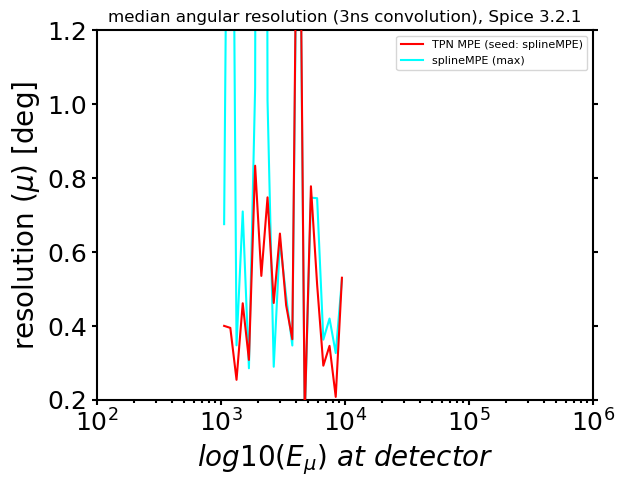

In [8]:
fig, ax = plt.subplots()
plot_args = {'xlabel':'$log10(E_{\\mu})\,\,at\,\,detector$', 
                 'ylabel':'resolution ($\mu$) [deg]', 
                 'xlim':[10**2.0, 10**6.0], 
                 'ylim':[0.2, 1.2]}

ax.plot(10**xvals, r_seed_smpe[1], color='red', label='TPN MPE (seed: splineMPE)', linestyle='solid', zorder=17)
# ax.plot(10**xvals, r_seed_truth[1], color='purple', label='TPN MPE (seed: truth)', linestyle='dashed', zorder=17)
ax.plot(10**xvals, r_smpe[1], color='cyan', label='splineMPE (max)')

adjust_plot_1d(fig, ax, plot_args=plot_args)
plt.xscale('log')
plt.title('median angular resolution (3ns convolution), Spice 3.2.1')
ax.set_yticks([0.2*i for i in range(9)][1:-2])
plt.legend(fontsize=8, loc='upper right')
plt.show()